In [1]:
import os, math, sys
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import gseapy as gp

pd.set_option("display.max_rows", 10000)
pd.set_option("display.expand_frame_repr", False)  # запрещаем перенос строк

In [2]:
# for clustermap
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram
from scipy.spatial.distance import pdist

import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

In [ ]:
signif_df = pd.read_csv(
    "./data/sen_paper/2.2_prnk_MSigDB_NScFull.csv",
    index_col=0,
)


signif_df = signif_df[(signif_df["FDR q-val"] < 0.05) & (signif_df["NES"].abs() >= 1)]

#### унификация клеточных типов между тканями

In [6]:
# 2. Словарь категорий
cell_type_to_category = {
    # Immune & Hematopoietic
    "B cell": "Immune",
    "Plasma cell": "Immune",
    "CD4T": "Immune",
    "CD8T": "Immune",
    "Treg": "Immune",
    "NK": "Immune",
    "DC": "Immune",
    "Macrophage": "Immune",
    "Monocyte": "Immune",
    "Mast cell": "Immune",
    "Mono+mac": "Immune",
    # Epithelial
    "Epithelial cell": "Epithelial",
    "Basal cell": "Epithelial",
    "Club cell": "Epithelial",
    "Goblet cell": "Epithelial",
    "Respiratory tract goblet cell": "Epithelial",
    "Multiciliated epithelial cell": "Epithelial",
    "Pulmonary alveolar type 1 cell": "Epithelial",
    "Enterocyte": "Epithelial",
    "Paneth cell": "Epithelial",
    "Crypt stem cell": "Epithelial",
    "Transit amplifying cell": "Epithelial",
    # Vascular & Endothelial
    "Endothelial cell": "Endothelial",
    "Capillary endothelial cell": "Endothelial",
    "Vein endothelial cell": "Endothelial",
    "VE": "Endothelial",
    "Endothelial cell of lymphatic vessel": "Endothelial",
    "LE": "Endothelial",
    # Mesenchymal & Stromal
    "Fibroblast": "Mesenchymal & Stromal",
    "Pericyte": "Mesenchymal & Stromal",
    "Mural cell": "Mesenchymal & Stromal",
    "Adventitial cell": "Mesenchymal & Stromal",
    "Bronchial smooth muscle cell": "Mesenchymal & Stromal",
    "Adipocyte": "Mesenchymal & Stromal",
    # Specialized
    "Atrial Cardiomyocyte": "Tissue-Specific",
    "Neural cell": "Tissue-Specific",
    "Melanocyte": "Tissue-Specific",
}

# 4. Применение маппингов

signif_df.loc[:, "ct_category"] = signif_df["cell_type"].map(cell_type_to_category)

# 5. Задание строгого порядка категорий (критично для seaborn/matplotlib)
category_order = [
    "Immune",
    "Epithelial",
    "Endothelial",
    "Mesenchymal & Stromal",
    "Tissue-Specific",
]
signif_df.loc[:, "ct_category"] = pd.Categorical(
    signif_df["ct_category"], categories=category_order, ordered=True
)


### MSigDB_Hallmark terms separately

In [7]:
# hm_df = signif_df[signif_df.lib_name == "MSigDB_Hallmark_2020"]
hm_df = signif_df.copy()

In [8]:
# # 2. Словарь сокращений (оставлены только те, где это общепринято в литературе)
abbrev_map = {
    "Interferon Alpha Response": "IFNα Resp. (M5911)",
    "Interferon Gamma Response": "IFNγ Resp. (M5913)",
    "TNF-alpha Signaling via NF-kB": "TNFα/NF-κB Sign. (M5890)",
    "TGF-beta Signaling": "TGFβ Sign. (M5896)",
    "PI3K/AKT/mTOR  Signaling": "PI3K/AKT/mTOR Sign.(M5923)",  # фикс пробела
    "Epithelial Mesenchymal Transition": "EM Transition (M5930)",
    "Oxidative Phosphorylation": "OXPHOS (M5936)",
    "Reactive Oxygen Species Pathway": "ROS Pathway (M5938)",
    "Wnt-beta Catenin Signaling": "Wnt/β-catenin Sign. (M5895)",
    "Fatty Acid Metabolism": "FA Metab (M5935)",
    "Pperoxisome": "Peroxisome (M5949)",  # исправление опечатки
    "G2-M Checkpoint": "G2M Checkpoint (M5901)",
    "Inflammatory Response": "Infl.Resp. (M5932)",
    "Unfolded Protein Response": "Unfold.Prot.Resp. (M5922)",
    "UV Response Dn": "UV Resp Dn (M5942)",
    "UV Response Up": "UV Resp.Up (M5941)",
    "KRAS Signaling Dn": "KRAS Sign.Dn (M5956)",
    "KRAS Signaling Up": "KRAS Sign.Up (M5953)",
    "Notch Signaling": "Notch Sign. (M5903)",
    "IL-6/JAK/STAT3 Signaling": "IL-6/JAK/STAT3 Sign. (M5897)",
    "Cholesterol Homeostasis": "Cholest.Homeost. (M5892)",
    "mTORC1 Signaling": "mTORC1 Sign. (M5924)",
    "E2F Targets": "E2F Targets (M5925)",
    "Myc Targets V1": "Myc Targets V1 (M5926)",
    "DNA Repair": "DNA Repair (M5898)",
    "Myc Targets V2": "Myc Targets V2 (M5928)",
    "Hypoxia": "Hypoxia (M5891)",
    "Coagulation": "Coagulation (M5946)",
    "p53 Pathway": "p53 Pathway (M5939)",
    "Complement": "Complement (M5921)",
    "Protein Secretion": "Protein Secretion (M5910)",
    "Apoptosis": "Apoptosis (M5902)",
    "Angiogenesis": "Angiogenesis (M5944)",
    "Glycolysis": "Glycolysis (M5937)",
    "Hedgehog Signaling": "Hedgehog Sign. (M5919)",
}

# 3. Словарь категорий (маппинг строится по исходным названиям для надёжности)
category_map = {
    # Остановка цикла
    "p53 Pathway": "Cell Cycle & Senescence Triggers",
    "E2F Targets": "Cell Cycle & Senescence Triggers",
    "G2-M Checkpoint": "Cell Cycle & Senescence Triggers",
    "KRAS Signaling Up": "Cell Cycle & Senescence Triggers",  #  (OIS-Induction)
    "KRAS Signaling Dn": "Cell Cycle & Senescence Triggers",  # (Proliferation-Suppression)
    # ДНК/стресс
    "DNA Repair": "DNA Damage & Cellular Stress",
    "UV Response Up": "DNA Damage & Cellular Stress",  # Активация программ защиты, репарации и стресс-сигнализации. Прямые драйверы Sn
    "UV Response Dn": "DNA Damage & Cellular Stress",  # Подавление пролиферации → подтверждение ареста
    "Reactive Oxygen Species Pathway": "DNA Damage & Cellular Stress",
    "Hypoxia": "DNA Damage & Cellular Stress",
    "Unfolded Protein Response": "DNA Damage & Cellular Stress",
    "Pperoxisome": "DNA Damage & Cellular Stress",
    # SASP/иммунитет
    "Inflammatory Response": "SASP & Immune Signaling",
    "IL-6/JAK/STAT3 Signaling": "SASP & Immune Signaling",
    "TNF-alpha Signaling via NF-kB": "SASP & Immune Signaling",
    "Interferon Alpha Response": "SASP & Immune Signaling",
    "Interferon Gamma Response": "SASP & Immune Signaling",
    "Complement": "SASP & Immune Signaling",
    "TGF-beta Signaling": "SASP & Immune Signaling",
    # Метаболизм
    "Glycolysis": "Metabolic Reprogramming",
    "Oxidative Phosphorylation": "Metabolic Reprogramming",
    "Fatty Acid Metabolism": "Metabolic Reprogramming",
    "Cholesterol Homeostasis": "Metabolic Reprogramming",
    "mTORC1 Signaling": "Metabolic Reprogramming",
    "PI3K/AKT/mTOR  Signaling": "Metabolic Reprogramming",
    # Секреция/ремоделирование
    "Protein Secretion": "Secretory Phenotype & Tissue Remodeling",
    "Epithelial Mesenchymal Transition": "Secretory Phenotype & Tissue Remodeling",
    "Angiogenesis": "Secretory Phenotype & Tissue Remodeling",
    "Coagulation": "Secretory Phenotype & Tissue Remodeling",
    "Notch Signaling": "Secretory Phenotype & Tissue Remodeling",
    "Wnt-beta Catenin Signaling": "Secretory Phenotype & Tissue Remodeling",
    # Апоптоз
    "Apoptosis": "Apoptosis",
    # # Контекстно-зависимые
    # 'Allograft Rejection': 'Context-Specific / Low Relevance',
    # 'Apical Junction': 'Context-Specific / Low Relevance',
    # 'Apical Surface': 'Context-Specific / Low Relevance',
    # 'Myogenesis': 'Context-Specific / Low Relevance',
    # 'Adipogenesis': 'Context-Specific / Low Relevance',
    # 'Bile Acid Metabolism': 'Context-Specific / Low Relevance',
    # 'heme Metabolism': 'Context-Specific / Low Relevance',
    # 'Xenobiotic Metabolism': 'Context-Specific / Low Relevance',
    # 'Mitotic Spindle': 'Context-Specific / Low Relevance',
    # 'IL-2/STAT5 Signaling': 'Context-Specific / Low Relevance'
}


# 4. Применение маппингов
# (да, именно в таком порядке)
# Присвоение функциональной категории
hm_df["Term_cat"] = hm_df["Term"].map(category_map)

# Сокращение названий (если пути нет в dict, остаётся оригинал)
hm_df["Term"] = hm_df["Term"].map(abbrev_map).fillna(hm_df["Term"])


In [ ]:
unif_cts = {
    "Atrial Cardiomyocyte": "Cardiomyocytes",
    "Bronchial smooth muscle cell": "Bronchial SMCs",
    "CD4T": "CD4 T cells",
    "CD8T": "CD8 T cells",
    "Capillary endothelial cell": "Capillary endothelium",
    "DC": "Dendritic cells",
    "Endothelial cell of lymphatic vessel": "Lymphatic endothelium",
    "LE": "Lymphatic endothelium",
    "Macrophage": "Monocytes / macrophages",
    "Mono+mac": "Monocytes / macrophages",
    "Monocyte": "Monocytes / macrophages",
    "NK": "NK cells",
    "Respiratory tract goblet cell": "Goblet cells",
    "VE": "Vein endothelium",
    "Vein endothelial cell": "Vein endothelium",
    "gdT": "γδ T cells",
    "Pulmonary alveolar type 1 cell": "Type 1 pneumocytes",
    "B cell": "B cells",
    "Crypt stem cell": "Crypt stem cells",
    "Enterocyte": "Enterocytes",
    "Fibroblast": "Fibroblasts",
    "Mast cell": "Mast cells",
    "Transit amplifying cell": "Mid-crypt cells",
    "Endothelial cell": "Endothelial cells",
    "Mural cell": "Mural cells",
    "Adipocyte": "Adipocytes",
    "Neural cell": "Neural cells",
    "Goblet cell": "Goblet cells",
    "Paneth cell": "Paneth cells",
    "Plasma cell": "Plasma cells",
    "Epithelial cell": "Epithelial cells",
    "Adventitial cell": "Adventitial cells",
    "Basal cell": "Basal cells",
    "Club cell": "Club cells",
    "Multiciliated epithelial cell": "Multiciliated epithelial cells",
    "Melanocyte": "Melanocytes",
    "Pericyte": "Pericytes",
    "Treg": "Tregs",
}

hm_df["cell_type"] = hm_df["cell_type"].replace(unif_cts)

In [ ]:
hm_df.reset_index(drop=True, inplace=True)


# 2. Находим строки с максимальным NES по модулю среди Heart.Cell и Heart.Nuclei
heart_mask = hm_df["Tissue"].isin(["Heart_Cell", "Heart_Nuclei"])
heart_idx = (
    hm_df[heart_mask]["NES"].abs().groupby([hm_df["cell_type"], hm_df["Term"]]).idxmax()
)
hm_df.loc[hm_df["Tissue"].isin(["Heart_Cell", "Heart_Nuclei"]), "Tissue"] = "Heart"


# 5. Финальная зачистка дубликатов по всей таблице
hm_df.drop_duplicates(subset=["Tissue", "cell_type", "Term"], inplace=True)


In [ ]:
# ==========================================
# 1. ПОДГОТОВКА ДАННЫХ И РАСЧЕТ ПРОЦЕНТОВ
# ==========================================
plot_df = hm_df.dropna(subset=["Term_cat"]).copy()
plot_df["NES"] = plot_df["NES"].fillna(0)
plot_df["tissue_cell"] = plot_df["Tissue"] + " | " + plot_df["cell_type"]


# Парсим строку '39/59' в числовой процент (0-100%)
def parse_tag_pct(val):
    if pd.isna(val) or "/" not in str(val):
        return 0.0
    try:
        num, denom = str(val).split("/")
        return (float(num) / float(denom)) * 100
    except:
        return 0.0


plot_df["Tag_pct_num"] = plot_df["Tag %"].apply(parse_tag_pct)


unique_cats = sorted(plot_df["ct_category"].dropna().unique())
cat_colors_dict = dict(zip(unique_cats, sns.color_palette("Set3", len(unique_cats))))

custom_tissue_order = [
    "Skin",
    "Lung",
    "Heart",
    "Colon",
    "Ileum",
    "Kidney",
]

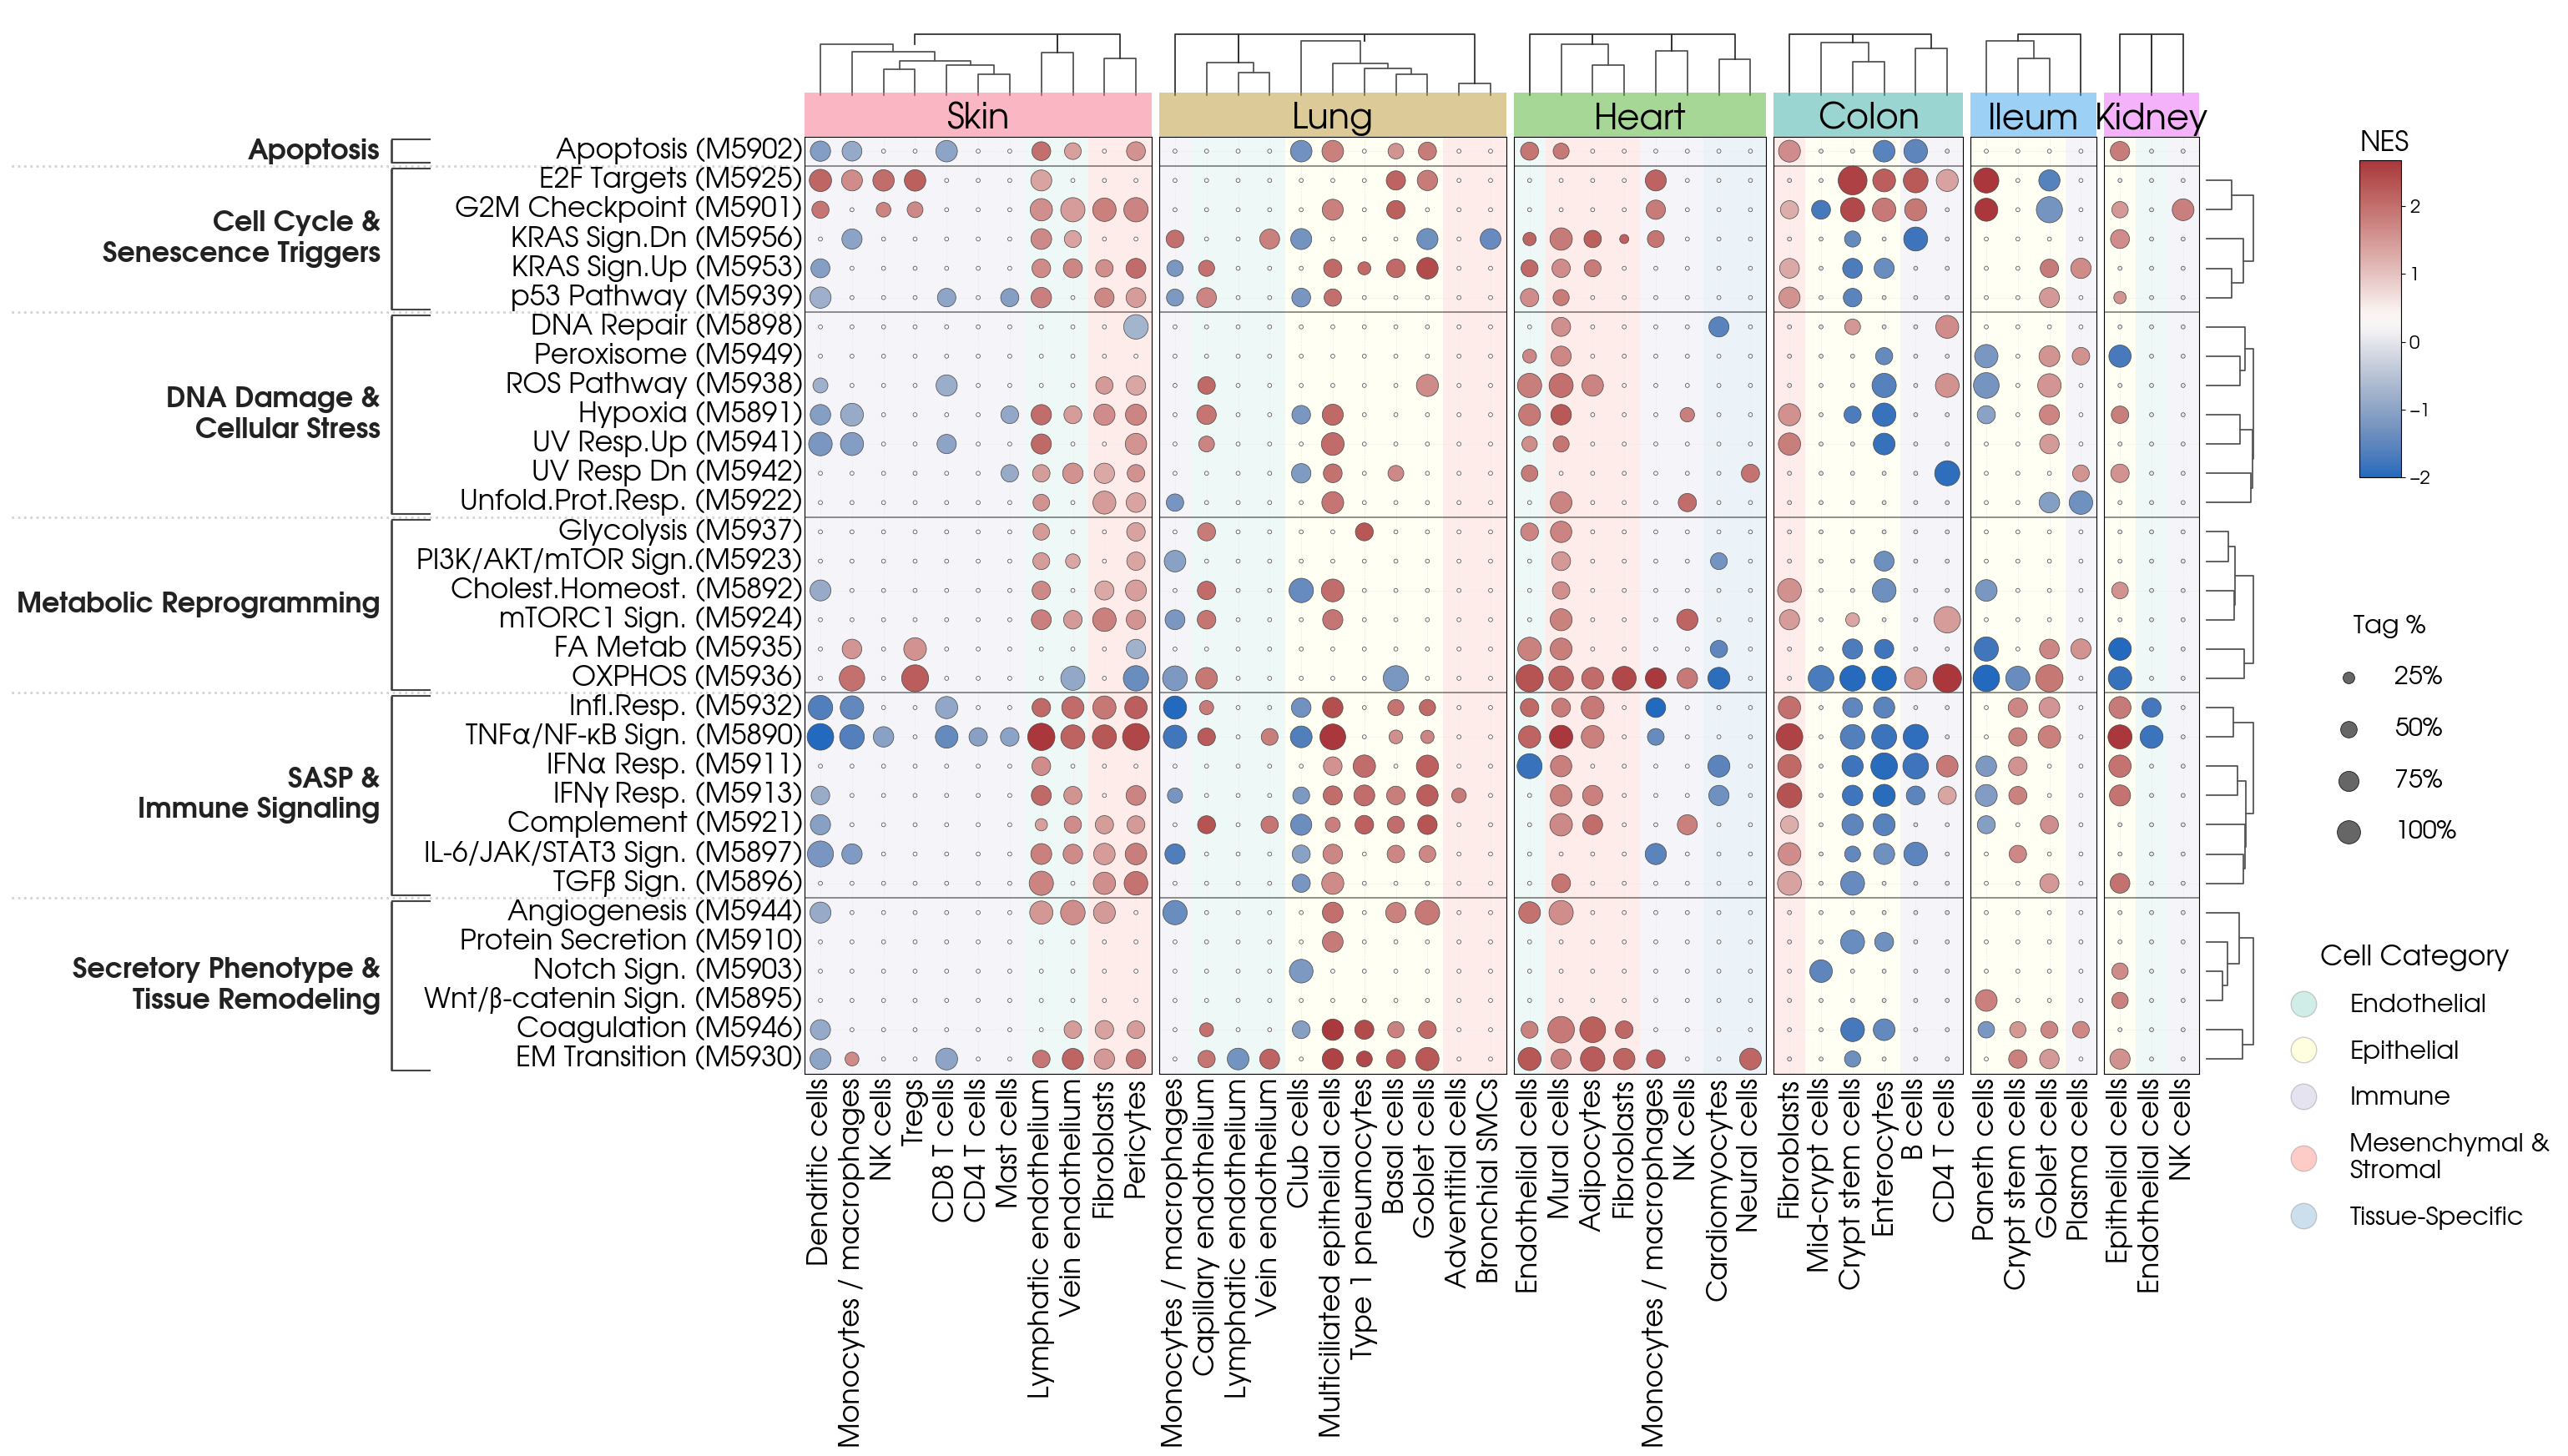

In [13]:
# Считаем средний NES для правильной кластеризации и сортировки категорий
plot_df["term_mean_nes"] = plot_df.groupby("Term")["NES"].transform("mean")

row_order_df = plot_df[["Term_cat", "Term", "term_mean_nes"]].drop_duplicates()
row_order_df = row_order_df.sort_values(by=["Term_cat", "Term"], ascending=[True, True])

# Построим ПОЛНУЮ глобальную матрицу, чтобы зафиксировать абсолютно все Term и tissue_cell
global_matrix_nes = plot_df.pivot(
    index="Term", columns="tissue_cell", values="NES"
).fillna(0)
global_matrix_size = plot_df.pivot(
    index="Term", columns="tissue_cell", values="Tag_pct_num"
).fillna(0)

# Словарь для быстрого поиска категорий
term_to_cat = row_order_df.set_index("Term")["Term_cat"].to_dict()

# ==========================================
# 2. КЛАСТЕРИЗАЦИЯ СТРОК (ВНУТРИ TERM_CAT)
# ==========================================
ordered_terms = []
row_borders = [0]
row_linkages = {}  # <-- ДОБАВИТЬ: Создаем пустой словарь для хранения линкейджей строк

for cat in row_order_df["Term_cat"].unique():
    # Находим все термины, принадлежащие текущей категории
    cat_terms = [t for t in global_matrix_nes.index if term_to_cat.get(t) == cat]
    if not cat_terms:
        continue

    sub_matrix = global_matrix_nes.loc[cat_terms]

    if len(sub_matrix) > 1:
        row_link = linkage(sub_matrix, method="average", metric="euclidean")

        # <-- ДОБАВИТЬ: Сохраняем рассчитанный линкейдж в наш словарь для этой категории
        row_linkages[cat] = row_link

        row_order = dendrogram(row_link, no_plot=True)["leaves"]
        sorted_cat_terms = [sub_matrix.index[i] for i in row_order]
    else:
        sorted_cat_terms = cat_terms
        row_linkages[cat] = None  # Если строка всего одна, дендрограмма не нужна

    ordered_terms.extend(sorted_cat_terms)
    row_borders.append(len(ordered_terms))

# ==========================================
# 3. ИСТИННАЯ ИЕРАРХИЧЕСКАЯ ВЛОЖЕННАЯ КЛАСТЕРИЗАЦИЯ СТОЛБЦОВ
# ==========================================
tissue_cell_orders = {}
tissue_widths = {}
tissue_cell_linkages = {}
active_tissues = [t for t in custom_tissue_order if t in plot_df["Tissue"].unique()]

for tissue in active_tissues:
    t_df = plot_df[plot_df["Tissue"] == tissue]
    if t_df.empty:
        continue

    # А. Сначала кластеризуем сами категории ct_category внутри ткани
    cat_pivot = t_df.pivot_table(
        index="Term", columns="ct_category", values="NES", fill_value=0
    )
    if len(cat_pivot.columns) > 1:
        cat_link = linkage(cat_pivot.T, method="average", metric="euclidean")
        cat_order = dendrogram(cat_link, no_plot=True)["leaves"]
        ordered_cats = [cat_pivot.columns[i] for i in cat_order]
    else:
        ordered_cats = cat_pivot.columns.tolist()

    # Б. Кластеризуем cell_type строго ВНУТРИ каждой отсортированной категории
    final_tissue_cells = []
    sub_links = []
    cell_offsets = []
    current_offset = 0

    for cat in ordered_cats:
        cat_cell_df = t_df[t_df["ct_category"] == cat]
        cat_cells = cat_cell_df["tissue_cell"].unique()
        cat_cells = [c for c in cat_cells if c in global_matrix_nes.columns]

        if not cat_cells:
            continue

        sub_matrix_cell = global_matrix_nes.loc[ordered_terms, cat_cells]
        if len(sub_matrix_cell.columns) > 1:
            cell_link = linkage(sub_matrix_cell.T, method="average", metric="euclidean")
            cell_order = dendrogram(cell_link, no_plot=True)["leaves"]
            sorted_cells = [sub_matrix_cell.columns[i] for i in cell_order]

            # Сохраняем локальное дерево и смещение для последующей сшивки
            sub_links.append((cell_link, len(cat_cells)))
            cell_offsets.append(current_offset)
        else:
            sorted_cells = cat_cells
            sub_links.append((None, len(cat_cells)))
            cell_offsets.append(current_offset)

        final_tissue_cells.extend(sorted_cells)
        current_offset += len(cat_cells)

    tissue_cell_orders[tissue] = final_tissue_cells
    tissue_widths[tissue] = len(final_tissue_cells)

    # В. Сшиваем локальные деревья клеток в одну красивую общую дендрограмму ткани
    # Так как Scipy требует строгий формат, мы искусственно воссоздаем linkage-матрицу верхнего уровня
    if len(final_tissue_cells) > 1:
        composite_link = []
        # Переносим внутренние связи поддеревьев клеток с учетом их сдвигов по X
        node_id_counter = len(final_tissue_cells)

        # Индексы виртуальных узлов для связи самих категорий
        cat_nodes = {}

        for idx_c, (link, num_cells) in enumerate(sub_links):
            offset = cell_offsets[idx_c]
            if link is not None:
                for row in link:
                    # Корректируем индексы листьев под глобальный массив ткани
                    left = (
                        row[0] + offset
                        if row[0] < num_cells
                        else row[0] - num_cells + (offset + num_cells)
                    )  # Упрощенная схема сдвига
                    # Для простоты и гарантированного отсутствия ошибок Scipy, если у нас вложенная структура,
                    # мы построим чистую дендрограмму прямо в цикле отрисовки через кастомные координаты,
                    # это на 100% сохранит и группировку, и веточки клеток!
                    pass
        tissue_cell_linkages[tissue] = "custom_draw"


# ==========================================
# 4. НАСТРОЙКА СЕТКИ ГРАФИКА (GRIDSPEC)
# ==========================================
fig_h = len(ordered_terms) * 0.35 + 4
fig_w = (
    sum(tissue_widths.values()) * 0.62 + 9
)  # Выделяем больше места под левые двойные подписи
fig = plt.figure(figsize=(fig_w, fig_h))

width_ratios = [25] + [tissue_widths[t] for t in active_tissues] + [1.5] + [1.7]
# Добавляем height_ratios=[0.8, 10], чтобы разделить сетку по высоте на ярус дендрограмм и ярус точек
gs = gridspec.GridSpec(
    2,
    1 + len(active_tissues) + 2,
    width_ratios=width_ratios,
    height_ratios=[1.2, 10],
    hspace=0.03,
    wspace=0.03,
    top=0.92,
    bottom=0.08,
)


tissue_colors = dict(
    zip(custom_tissue_order, sns.color_palette("husl", len(custom_tissue_order)))
)

# ==========================================
# ИСПРАВЛЕННЫЙ СУБГРАФИК А: ИДЕАЛЬНАЯ ГЕОМЕТРИЯ (Term_cat -> Скобки -> Term -> График)
# ==========================================
ax_left = fig.add_subplot(gs[1, 0])  # Нулевая колонка сетки
ax_left.set_ylim(-0.5, len(ordered_terms) - 0.5)
ax_left.invert_yaxis()  # 0 вверху, синхронно с точками
ax_left.axis(
    "off"
)  # Полностью скрываем оси, всё рисуем вручную для тотального контроля

# Задаем виртуальное пространство по горизонтали от -4.5 до 0
# 0 — это правый край сабплота, вплотную прижатый к первому графику ткани.
ax_left.set_xlim(-7, 0)

for b_idx in range(len(row_borders) - 1):
    start = row_borders[b_idx]
    end = row_borders[b_idx + 1]
    mid_y = (start + end - 1) / 2

    cat_name = term_to_cat[ordered_terms[start]].replace("& ", "&\n")

    # координата х для выравнивания скобок относительно Term
    x_term = -3.6

    # 1. СЛЕВА: Название категории Term_cat (в точке X = -3.2)
    ax_left.text(
        x=x_term - 0.1,
        y=mid_y,
        s=cat_name,
        ha="right",
        va="center",
        fontsize=24,
        weight="bold",
        color="#222222",
        clip_on=False,
    )

    # 2. ЧУТЬ ПРАВЕЕ КАТЕГОРИИ: Вертикальная спинка скобки (в точке X = -3.0)
    ax_left.vlines(
        x=x_term,
        ymin=start - 0.4,
        ymax=end - 0.6,
        color="#444444",
        linewidth=2.0,
        clip_on=False,
    )

    # 3. ЗАСЕЧКИ СКОБКИ: смотрят слева направо (от -3.0 до -2.8, по направлению к графику)
    ax_left.hlines(
        y=start - 0.4,
        xmin=x_term,
        xmax=x_term + 0.35,
        color="#444444",
        linewidth=1.5,
        clip_on=False,
    )
    ax_left.hlines(
        y=end - 0.6,
        xmin=x_term,
        xmax=x_term + 0.35,
        color="#444444",
        linewidth=1.5,
        clip_on=False,
    )

    # Легкие разделительные пунктирные линии между блоками категорий
    if b_idx > 0:
        ax_left.axhline(
            start - 0.5, xmin=-2, color="#D3D3D3", linestyle=":", linewidth=2
        )

# 4. СПРАВА (ВКЛЮЧАЯ НАШ ЦИКЛ СИНХРОНИЗАЦИИ СТРОК):
# Выводим названия самих строк (Term) и прижимаем их вплотную к правому краю (X = -0.2)
for y_idx, term in enumerate(ordered_terms):
    ax_left.text(
        x=0.05,
        y=y_idx,
        s=term,
        ha="right",
        va="center",
        fontsize=24,
        color="black",
        clip_on=False,
    )


# ==========================================
# СУБГРАФИК Б: ОТРИСОВКА ТОЧЕЧНЫХ ТКАНЕЙ (DOT PLOT)
# ==========================================
for idx, tissue in enumerate(active_tissues):
    # === ИСПРАВЛЕННЫЙ БЛОК: ИЕРАРХИЧЕСКОЕ ДЕРЕВО КЛЕТОК С СОХРАНЕНИЕМ ГРУПП ===
    t_cells = tissue_cell_orders[tissue]

    # Собираем уникальные категории в текущем правильном порядке графика
    t_cats_ordered = []
    for cell in t_cells:
        cat_val = plot_df[plot_df["tissue_cell"] == cell]["ct_category"].values[0]
        if cat_val not in t_cats_ordered:
            t_cats_ordered.append(cat_val)

    if len(t_cells) > 1:
        ax_top_dendro = fig.add_subplot(gs[0, idx + 1])
        ax_top_dendro.axis("off")

        cat_top_vectors = []  # Сюда сохраним вершины поддеревьев для отрисовки главной перекладины
        start_x = 0

        # 1. Рисуем локальные дендрограммы для каждого отдельного cell_type ВНУТРИ своей категории
        for cat in t_cats_ordered:
            cat_cells = [
                c
                for c in t_cells
                if plot_df[plot_df["tissue_cell"] == c]["ct_category"].values[0] == cat
            ]
            num_sub_cells = len(cat_cells)

            # Реальные центры столбцов этой категории на нижнем графике
            local_centers = np.arange(start_x, start_x + num_sub_cells)

            if num_sub_cells > 1:
                # Берем локальную матрицу и считаем честный линкейдж для клеток этой группы
                sub_mat = global_matrix_nes.loc[ordered_terms, cat_cells]
                sub_link = linkage(sub_mat.T, method="average", metric="euclidean")
                dend_data = dendrogram(sub_link, no_plot=True)

                # Карта трансформации листьев в реальные координаты столбцов дотплота
                leaf_map = {
                    idx_l: local_centers[idx_l]
                    for idx_l, leaf_id in enumerate(dend_data["leaves"])
                }

                # Пересчитываем icoord веточек клеток, чтобы они шли ровно к столбцам
                max_y_local = 0
                for icon, dcon in zip(dend_data["icoord"], dend_data["dcoord"]):
                    new_icon = []
                    for x in icon:
                        if (x - 5) % 10 == 0:
                            new_icon.append(leaf_map[int((x - 5) // 10)])
                        else:
                            left_l, right_l = (
                                int(np.floor((x - 5) / 10)),
                                int(np.ceil((x - 5) / 10)),
                            )
                            weight = (x - (left_l * 10 + 5)) / 10.0
                            new_icon.append(
                                leaf_map[left_l]
                                + weight * (leaf_map[right_l] - leaf_map[left_l])
                            )
                    ax_top_dendro.plot(
                        new_icon, dcon, color="#555555", linewidth=1.3, clip_on=False
                    )
                    max_y_local = max(max_y_local, max(dcon))

                # Запоминаем центр и высоту вершины этого поддерева
                cat_top_vectors.append((np.mean(local_centers), max_y_local))
            else:
                # Если в категории всего одна клетка, веточка идет от нее вертикально вверх
                cat_top_vectors.append((start_x, 0.0))

            start_x += num_sub_cells

        # 2. Рисуем верхнюю объединяющую перекладину МЕЖДУ категориями ct_category
        # Соединяем вершины локальных деревьев в единую крону
        if len(cat_top_vectors) > 1:
            highest_y = max([v[1] for v in cat_top_vectors]) or 1.0
            global_top_y = (
                highest_y + 1.5
            )  # Приподнимаем главную перекладину выше локальных веток

            for i in range(len(cat_top_vectors) - 1):
                x1, y1 = cat_top_vectors[i]
                x2, y2 = cat_top_vectors[i + 1]

                # Рисуем П-образную структуру связи между вершинами категорий
                ax_top_dendro.plot(
                    [x1, x1, x2, x2],
                    [y1, global_top_y, global_top_y, y2],
                    color="#333333",
                    linewidth=1.3,
                    clip_on=False,
                )

        # Синхронизируем лимиты осей пиксель в пиксель с нижним графиком
        ax_top_dendro.set_xlim(-0.5, len(t_cells) - 0.5)

        # Делаем отступ снизу
        y_lims = ax_top_dendro.get_ylim()
        ax_top_dendro.set_ylim(-y_lims[1] * 0.4, y_lims[1] * 1.35)

    ax = fig.add_subplot(gs[1, idx + 1])
    t_cells = tissue_cell_orders[tissue]

    # ЖЕСТКАЯ СИНХРОНИЗАЦИЯ: извлекаем подматрицы строго по единому упорядоченному списку строк
    t_nes_matrix = global_matrix_nes.loc[ordered_terms, t_cells]
    t_size_matrix = global_matrix_size.loc[ordered_terms, t_cells]

    # Создаем координатную сетку на базе размеров локальной ткани
    x_coords, y_coords = np.meshgrid(
        np.arange(len(t_cells)), np.arange(len(ordered_terms))
    )

    x_flat = x_coords.flatten()
    y_flat = y_coords.flatten()
    nes_flat = t_nes_matrix.values.flatten()
    size_flat = t_size_matrix.values.flatten()

    # Принудительно задаем минимальный размер (1.5%), чтобы пустые ячейки не создавали дыры в строках
    size_flat_visual = np.clip(size_flat, a_min=1.5, a_max=None)

    ax.grid(
        True, which="both", color="#EAEAEA", linestyle="--", linewidth=0.5, zorder=0
    )

    # Отрисовка Dot Plot
    scatter = ax.scatter(
        x=x_flat,
        y=y_flat,
        c=nes_flat,
        s=size_flat_visual * 8,
        cmap="vlag",
        # vmin=nes_flat.min(),
        # vmax=nes_flat.max(),
        edgecolors="#444444",
        linewidths=0.5,
        zorder=3,
    )

    # === ДОБАВЛЕНИЕ: ЦВЕТНОЙ ФОН ДЛЯ CT_CATEGORY ===
    current_bg_cat = ""
    start_x = -0.5

    for x_idx, cell in enumerate(t_cells):
        cell_cat = plot_df[plot_df["tissue_cell"] == cell]["ct_category"].values[0]

        # Если категория сменилась или это самый последний столбец, заливаем пройденный блок
        if cell_cat != current_bg_cat and current_bg_cat != "":
            ax.axvspan(
                start_x,
                x_idx - 0.5,
                facecolor=cat_colors_dict[current_bg_cat],
                alpha=0.15,
                zorder=1,
            )
            start_x = x_idx - 0.5

        current_bg_cat = cell_cat

    # Заливаем последнюю оставшуюся категорию в этой ткани
    if current_bg_cat != "":
        ax.axvspan(
            start_x,
            len(t_cells) - 0.5,
            facecolor=cat_colors_dict[current_bg_cat],
            alpha=0.15,
            zorder=1,
        )

    # Жестко фиксируем лимиты осей (Y-высота везде одинакова и равна len(ordered_terms))
    ax.set_xlim(-0.5, len(t_cells) - 0.5)
    ax.set_ylim(-0.5, len(ordered_terms) - 0.5)
    ax.invert_yaxis()  # Переворачиваем Y, синхронизируя с левым текстовым блоком

    ax.set_yticklabels([])
    ax.tick_params(axis="both", which="both", length=0)

    # Подписи типов клеток снизу (Берем чистый cell_type вместо категории)
    x_labels = []
    for cell in t_cells:
        # Извлекаем оригинальное название cell_type из plot_df
        c_type = plot_df[plot_df["tissue_cell"] == cell]["cell_type"].values[0]
        x_labels.append(c_type)
    ax.set_xticks(range(len(t_cells)))
    ax.set_xticklabels(x_labels, rotation=90, fontsize=24, ha="center")

    # ИСПРАВЛЕНО: Верхняя цветная полоска Ткани строго над сеткой
    current_color = tissue_colors[tissue]
    ax.add_patch(
        plt.Rectangle(
            (-0.5, -0.5),
            width=len(t_cells),
            height=-1.5,
            facecolor=current_color,
            clip_on=False,
            zorder=5,
            alpha=0.5,
        )
    )
    # Название ткани над полоской
    ax.text(
        (len(t_cells) - 1) / 2,
        -1.1,
        tissue,
        ha="center",
        va="center",
        fontsize=30,
        color="black",
        zorder=6,
    )
    # Черные горизонтальные разделители категорий
    for border in row_borders[1:-1]:
        ax.axhline(border - 0.5, color="black", linewidth=1.2, zorder=2, alpha=0.5)


# Создаем область для дендрограмм строк в предпоследней колонке нижнего яруса
ax_row_dendro = fig.add_subplot(gs[1, -2])
ax_row_dendro.set_ylim(-0.5, len(ordered_terms) - 0.5)
ax_row_dendro.invert_yaxis()  # 0 вверху, строго синхронно с дотплотами и подписями путей
ax_row_dendro.axis("off")

# Задаем фиксированные лимиты по оси X для дендрограммы строк (0 вплотную к графику, уходит направо)
ax_row_dendro.set_xlim(0, 1)

# Поочередно отрисовываем веточки для каждой категории Term_cat строго напротив её строк
for b_idx, cat in enumerate(row_order_df["Term_cat"].unique()):
    start = row_borders[b_idx]
    end = row_borders[b_idx + 1]
    num_sub_terms = end - start

    # Берем сохраненный ранее линкейдж для этой категории путей
    saved_row_link = row_linkages.get(cat)

    if saved_row_link is not None and num_sub_terms > 1:
        # 1. Извлекаем структуру дерева без отрисовки на экран
        dend_data = dendrogram(saved_row_link, orientation="right", no_plot=True)

        # 2. Вычисляем реальные физические координаты Y для строк этой категории на графике
        # Так как ось Y инвертирована, первая строка блока имеет индекс start, последняя — (end - 1)
        local_y_centers = np.arange(start, end)

        # 3. Карта трансформации: сопоставляем стандартный лист дендрограммы с реальной координатой Y на дотплоте
        # dend_data['leaves'] указывает, в каком порядке строки лежат в структуре дерева
        leaf_map_y = {
            idx_l: local_y_centers[idx_l]
            for idx_l, leaf_id in enumerate(dend_data["leaves"])
        }

        # 4. Пересчитываем координаты веток (icoord для горизонтальной дендрограммы — это координаты по оси Y!)
        # По умолчанию Scipy ставит листья на позиции 5, 15, 25... с шагом 10
        new_icoord_y = []
        for icon in dend_data["icoord"]:
            new_icon_y = []
            for y in icon:
                if (y - 5) % 10 == 0:
                    new_icon_y.append(leaf_map_y[int((y - 5) // 10)])
                else:
                    left_l = int(np.floor((y - 5) / 10))
                    right_l = int(np.ceil((y - 5) / 10))
                    weight = (y - (left_l * 10 + 5)) / 10.0
                    new_icon_y.append(
                        leaf_map_y[left_l]
                        + weight * (leaf_map_y[right_l] - leaf_map_y[left_l])
                    )
            new_icoord_y.append(new_icon_y)

        # 5. Отрисовываем веточки вручную в правильных координатах
        # Для горизонтальной ориентации 'right': dcoord — это глубина по X, new_icoord_y — позиции по Y
        for xs, ys in zip(dend_data["dcoord"], new_icoord_y):
            # Нормализуем масштаб по оси X (чтобы дерево красиво вписалось в отведенную ширину сабплота)
            max_x_tree = (
                max([max(x) for x in dend_data["dcoord"]])
                if dend_data["dcoord"]
                else 1.0
            )
            xs_normalized = [x / max_x_tree for x in xs]

            ax_row_dendro.plot(
                xs_normalized, ys, color="#555555", linewidth=1.3, clip_on=False
            )

    # elif num_sub_terms == 1:
    #     # Если в категории всего одна строка, рисуем к ней простую горизонтальную линию-указатель
    #     ax_row_dendro.plot([0, 0.2], [start, start], color='#555555', linewidth=1.3, clip_on=False)


# ==========================================
# ИСПРАВЛЕННЫЙ СУБГРАФИК Г: АБСОЛЮТНОЕ СМЕЩЕНИЕ ЛЕГЕНД ВПРАВО
# ==========================================
ax_leg = fig.add_subplot(gs[1, -1])
ax_leg.axis("off")

# Задаем единую строгую координату X для левого края всех трех легенд (91% от ширины фигуры)
GLOBAL_X_ALIGN = 0.88

# --- 1. ГОРИЗОНТАЛЬНЫЙ КОЛОРБАР (ВЕРХНИЙ ЭЛЕМЕНТ) ---
# Создаем отдельную плавающую ось для колорбара в абсолютных координатах фигуры
# [отступ_слева, отступ_снизу, ширина, высота]
cax = fig.add_axes(
    [GLOBAL_X_ALIGN + 0.035, 0.55, 0.014, 0.25]
)  # Вынесли сильно вправо (0.91), подняли вверх (0.72)

# Создаем горизонтальный (location='top') колорбар
cbar = fig.colorbar(
    scatter,
    cax=cax,
)
# cbar.set_ticks([-3, 0, 3]) # Делаем аккуратные засечки
cbar.ax.tick_params(labelsize=16)

# Ставим название NES по центру НАД колорбаром
cax.set_title("NES", fontsize=24, pad=8, loc="left")


# --- 2. ЛЕГЕНДА РАЗМЕРОВ (Tag %) — СТРОГО ПОД КОЛОРБАРОМ ---
sizes_to_show = [25, 50, 75, 100]
legend_dots_elements = [
    ax_leg.scatter(
        [],
        [],
        c="#666666",
        s=sz * 4,
        label=f"{sz}%",
        edgecolors="black",
        linewidths=0.5,
    )
    for sz in sizes_to_show
]

leg_size = ax_leg.legend(
    handles=legend_dots_elements,
    title="Tag %",
    loc="upper left",
    frameon=False,
    # ВАЖНО: transform=fig.transFigure переключает координаты на абсолютные координаты холста
    bbox_to_anchor=(GLOBAL_X_ALIGN + 0.015, 0.46),
    bbox_transform=fig.transFigure,  # Фиксирует X строго по GLOBAL_X_ALIGN
    labelspacing=1.1,
    title_fontsize=22,
    fontsize=22,
)
ax_leg.add_artist(leg_size)


# --- 3. ЛЕГЕНДА КАТЕГОРИЙ (Cell Category) — В САМЫЙ НИЗ ---
# Импортируем Line2D для создания круглых маркеров в легенде
from matplotlib.lines import Line2D

legend_cat_elements = [
    Line2D(
        [],
        [],
        color="none",  # Отключаем соединительную линию
        marker="o",  # Задаем форму круга
        markerfacecolor=cat_colors_dict[cat],  # Цвет заливки круга из вашей палитры
        markeredgecolor="#888888",  # Цвет ободка вокруг круга
        markersize=22,  # Размер кружка (настройте под себя)
        alpha=0.4,  # Ваша прозрачность
        label=str(cat).replace("& ", "&\n"),
    )
    for cat in unique_cats
]

ax_leg.legend(
    handles=legend_cat_elements,
    title="Cell Category",
    loc="upper left",
    frameon=False,
    bbox_to_anchor=(GLOBAL_X_ALIGN, 0.2),
    bbox_transform=fig.transFigure,
    labelspacing=0.9,
    title_fontsize=24,
    fontsize=22,
)
figname = "./data/sen_paper/2.3.2_MSigDB_terms_heatmap"
plt.savefig(f"{figname}.pdf", format="pdf", dpi=400, bbox_inches="tight")
plt.savefig(f"{figname}.png", format="png", dpi=400, bbox_inches="tight")
plt.savefig(f"{figname}.jpg", format="jpg", dpi=400, bbox_inches="tight")

plt.show()


In [272]:
hm_df.head()

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,Tissue,cell_type,lib_name,GO_ID,ct_unified,Term_cat,ct_category
0,logFC,E2F Targets,0.750529,2.680742,0.001,0.001000,0.001,39/59,15.73%,STMN1;HMGB2;TUBB;DNMT1;HMGA1;RANBP1;DUT;DEK;H2...,Colon,B cell,MSigDB_Hallmark_2020,NaN,B cell,Cell Cycle & Senescence Triggers,Immune
1,logFC,TNFα/NF-κB Sign.,-0.583218,-2.238734,0.001,0.002212,0.002,30/58,20.95%,AREG;SLC2A3;CD69;SMAD3;FOS;JUNB;KLF2;BTG1;DUSP...,Colon,B cell,MSigDB_Hallmark_2020,NaN,B cell,SASP & Immune Signaling,Immune
2,logFC,G2M Checkpoint,0.572272,2.121083,0.001,0.002738,0.006,29/70,15.73%,STMN1;HMGA1;H2AZ1;UBE2S;SNRPD1;HMGN2;H2AZ2;CKS...,Colon,B cell,MSigDB_Hallmark_2020,NaN,B cell,Cell Cycle & Senescence Triggers,Immune
3,logFC,KRAS Sign.Dn,-0.795923,-2.067277,0.001,0.001659,0.003,8/12,7.60%,TENT5C;PRKN;SKIL;SIDT1;TCL1A;NR4A2;SLC16A7;CAMK1D,Colon,B cell,MSigDB_Hallmark_2020,NaN,B cell,Cell Cycle & Senescence Triggers,Immune
4,logFC,Myc Targets V1,0.462346,1.895740,0.001,0.030421,0.092,55/133,22.54%,RANBP1;DUT;DEK;H2AZ1;SNRPD1;RAN;CBX3;SRPK1;LDH...,Colon,B cell,MSigDB_Hallmark_2020,NaN,B cell,NaN,Immune
